In [335]:
from py_files.setup import *
setup_notebook()

import matplotlib.colors as mcolors
import py_files.LS_aggregator as LS_aggregator

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# `Aggregate labour share` - *properly calculated*

*`1. get the GVA for every year`*

In [336]:
# 0. extraction helper
def code_token(x: pd.Index) -> pd.Series:
    s = pd.Series(x, dtype="string")
    return s.str.extract(r"^\s*([^ ]+)", expand=False)

# 1. extract codes
m_code = code_token(var_groups.mothers)          
s_code = code_token(var_groups.subs)     

# 2. mother letter of sub
s_mother = s_code.str[0]
groups = s_code.groupby(s_mother).apply(list).to_dict()

In [337]:
NABP36 = DstApi('NABP36')
# NABP36.variable_levels('TRANSAKT',language='en')
# df.loc[df["id"].eq("B2A3GD"), "text"].iloc[0]

In [338]:
NABP36 = DstApi('NABP36')

# 1. set up relevant inputs
transact = [
    'B1GD',  # B.1g Gross value added
    'D1D',   # D.1 Compensation of employees
    'B2A3GD',
]

# 2. set up fetch
params_e = {
    'table': 'NABP36',
    'format': 'BULK',
    'lang': 'en',
    'variables': [
        {'code': 'PRISENHED', 'values': ['V']},     # current prices (m. DKK)
        {'code': 'Tid', 'values': ['*']},
        {'code': 'BRANCHE', 'values': ['*']},
        {'code': 'TRANSAKT', 'values': transact}
        ]
}

# 3. get and clean
df_e_ = NABP36.get_data(params=params_e)
df_e_['INDHOLD'] = pd.to_numeric(df_e_['INDHOLD'], errors='coerce')

df_e = df_e_.pivot_table(
    index=['TID','BRANCHE'],
    columns='TRANSAKT',
    values='INDHOLD'
).reset_index()

df_e = df_e.rename(columns={
    'B.1g Gross value added'   : 'GVA',
    'D.1 Compensation of employees': 'e_comp',
    'B.2g+B.3g Gross operating surplus and mixed income':'e_mixed_inc'
})

df_e['e_total'] = df_e['e_comp'] # + 1/3 * df_e['e_mixed_inc'] 

# 4. compute labor share by industry
df_e['labor_share'] = df_e['e_total'] / df_e['GVA'] * 100

df_e_slim = df_e[['TID','BRANCHE','labor_share','GVA']].copy()

# 5. drop total
df_e_slim = df_e_slim[~df_e_slim['BRANCHE'].eq('Total')].copy()

# 6. extract industry code
df_e_slim['branche_code'] = code_token(df_e_slim['BRANCHE'])

*`2. get equity to wage income ratio`*

In [339]:
INDKP201 = DstApi('INDKP201')
INDKP201.tablesummary(language='en')
# INDKP201.variable_levels('Tid',language='en')

# 1. set up relevant inputs
inc = [
    '115',  # 4 Wages and salaries etc., total
    '225',  # 26 Capital income, gross (27+28) 
]

# 2. set up fetch
params_wc = {
    'table': 'INDKP201',
    'format': 'BULK',
    'lang': 'en',
    'variables': [
        {'code': 'INDKOMSTTYPE', 'values':  inc},  
        {'code': 'KOEN', 'values':          ['MOK']},
        {'code': 'ALDER', 'values':         ['14TOT']},
        {'code': 'POPU', 'values':          ['5020']},  # only those with the type
        {'code': 'PRISENHED', 'values':     ['005']},   # constant prices
        {'code': 'ENHED', 'values':         ['0050','0055','0060','0065']}, # mean, first, median, third quartile
        {'code': 'Tid', 'values':           ['*']},
        ]
}

# 3. download
df_wc_ = INDKP201.get_data(params=params_wc)
df_wc_['INDHOLD'] = pd.to_numeric(df_wc_['INDHOLD'], errors='coerce')

df_wc_ = df_wc_[['INDKOMSTTYPE','ENHED','TID','INDHOLD']].copy()
df_wc = df_wc_.pivot_table(
    index=['TID','ENHED'],
    columns='INDKOMSTTYPE',
    values='INDHOLD'
).reset_index()

# 4. compute share per type
# de_mean = (
#     df_wc.groupby('ENHED')['26 Capital income, gross (27+28)'].transform('mean') / 
#     df_wc.groupby('ENHED')['4 Wages and salaries etc., total'].transform('mean')
# )
df_wc['capinc_share'] = df_wc['26 Capital income, gross (27+28)'] / df_wc['4 Wages and salaries etc., total'] # - de_mean
df_wc_mean = df_wc[df_wc['ENHED'].eq('Mean (DKK)')][['TID','capinc_share']].copy()
# 'Third quartile (DKK)' 'Mean (DKK)'

# 5. merge with LS
df_e_slim = df_e_slim.merge(
    df_wc_mean,
    on='TID',
    how='left'
)

Table INDKP201: Main table for personal income statistics by type of income, sex, age, population, price unit, unit and time
Last update: 2025-12-01T08:00:00


*`3. plot`*

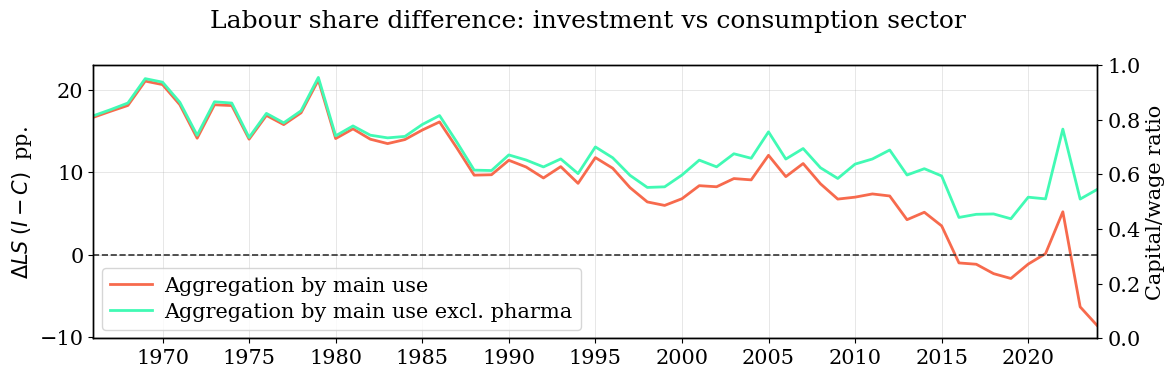

In [340]:
variations = {
    r'Aggregation by main use': 
        {'C': var_groups.consumption_industries, 'I': var_groups.investment_industries,
         },
        
    r'Aggregation by main use excl. pharma': 
        {'C': var_groups.consumption_industries, 'I': var_groups.investment_industries4},
}

res = LS_aggregator.plot_labor_share_variations(df_e_slim, variations)

*`4. get input labour shares`*

In [341]:
# 1. show both calibrations
years = [1970, 2020, 
        #  2022, 2023, 
         2024]
cols = ['C', 'I', 'diff']

with pd.option_context('display.float_format', '{:.4f}'.format):
    print(f'\nAggregation by main use\n')
    df = res['Aggregation by main use']
    out = df[df['TID'].isin(years)][['TID'] + cols].copy()
    out[cols] = out[cols] / 100
    print(out)

    print(f'\nAggregation by main use excl. pharma\n')
    df = res['Aggregation by main use excl. pharma']
    out = df[df['TID'].isin(years)][['TID'] + cols].copy()
    out[cols] = out[cols] / 100
    print(out)


Aggregation by main use

type   TID      C      I    diff
4     1970 0.5340 0.7404  0.2063
54    2020 0.6017 0.5904 -0.0113
58    2024 0.6063 0.5201 -0.0862

Aggregation by main use excl. pharma

type   TID      C      I   diff
4     1970 0.5340 0.7433 0.2093
54    2020 0.6017 0.6715 0.0698
58    2024 0.6063 0.6857 0.0794


*`5. Sanity`*

Check if calculated labour use shares match definitions.

In [342]:
# 1. assign type based on consumption and investment groupings
df_e_slim['type'] = np.select(
    [df_e_slim['branche_code'].isin(var_groups.consumption_industries),
        df_e_slim['branche_code'].isin(var_groups.investment_industries)],
    ['C', 'I'],
    default='x'
)

In [343]:
# 1. LS data
df_24 = df_e_slim[df_e_slim['TID'].eq(2024)][
    ['branche_code','labor_share','BRANCHE','GVA','type']].copy()

# 2. share data
year_result = il.compute_leontief_for_year(2024)
parent_shares = il.aggregate_use_shares_to_parent(year_result)

# 3. merge
df_merged = df_24.merge(
    parent_shares,
    left_on='branche_code',
    right_on='parent',
    how='left'
)

# 4. clean
df_m = df_merged[
    ['parent','type','labor_share','GVA','C_share','I_share','C_direct','I_direct']
    ].copy()

Processing year 2024...


In [344]:
df_m.sort_values('C_share', ascending=False, inplace=True)
df_m

,parent,type,labor_share,GVA,C_share,I_share,C_direct,I_direct
38,SB,C,100.000000,4882.0,100.000000,0.000000,100.000000,0.000000
26,LB,C,4.037388,195894.0,99.971981,0.028019,99.971981,0.028019
35,QB,C,97.639848,124653.0,99.831506,0.168494,99.854608,0.145392
34,QA,C,93.883925,123903.0,98.253297,1.746703,98.590244,1.409756
31,O,C,79.677963,121725.0,97.752650,2.247350,98.706605,1.293395
20,I,C,78.832879,42155.0,95.581280,4.418720,99.748316,0.251684
2,CA,C,62.294280,40893.0,94.480285,5.519715,95.824135,4.175865
0,A,C,53.080691,27153.0,93.790219,6.209781,97.860313,2.139687
37,SA,C,70.857947,36226.0,92.202436,7.797564,96.606772,3.393228
24,K,C,44.308840,142572.0,91.375754,8.624246,93.153891,6.846109


# `Industry labour share` - *per sector*

*prep data*

In [345]:
# 1. sort by type and GVA
df_24_i = df_24.sort_values(['type','GVA'], ascending=False).copy()

# 2. drop non I and C type
df_24_i = df_24_i[df_24_i['type'].isin(['C', 'I'])].copy() # removes 'Of'

*plot*

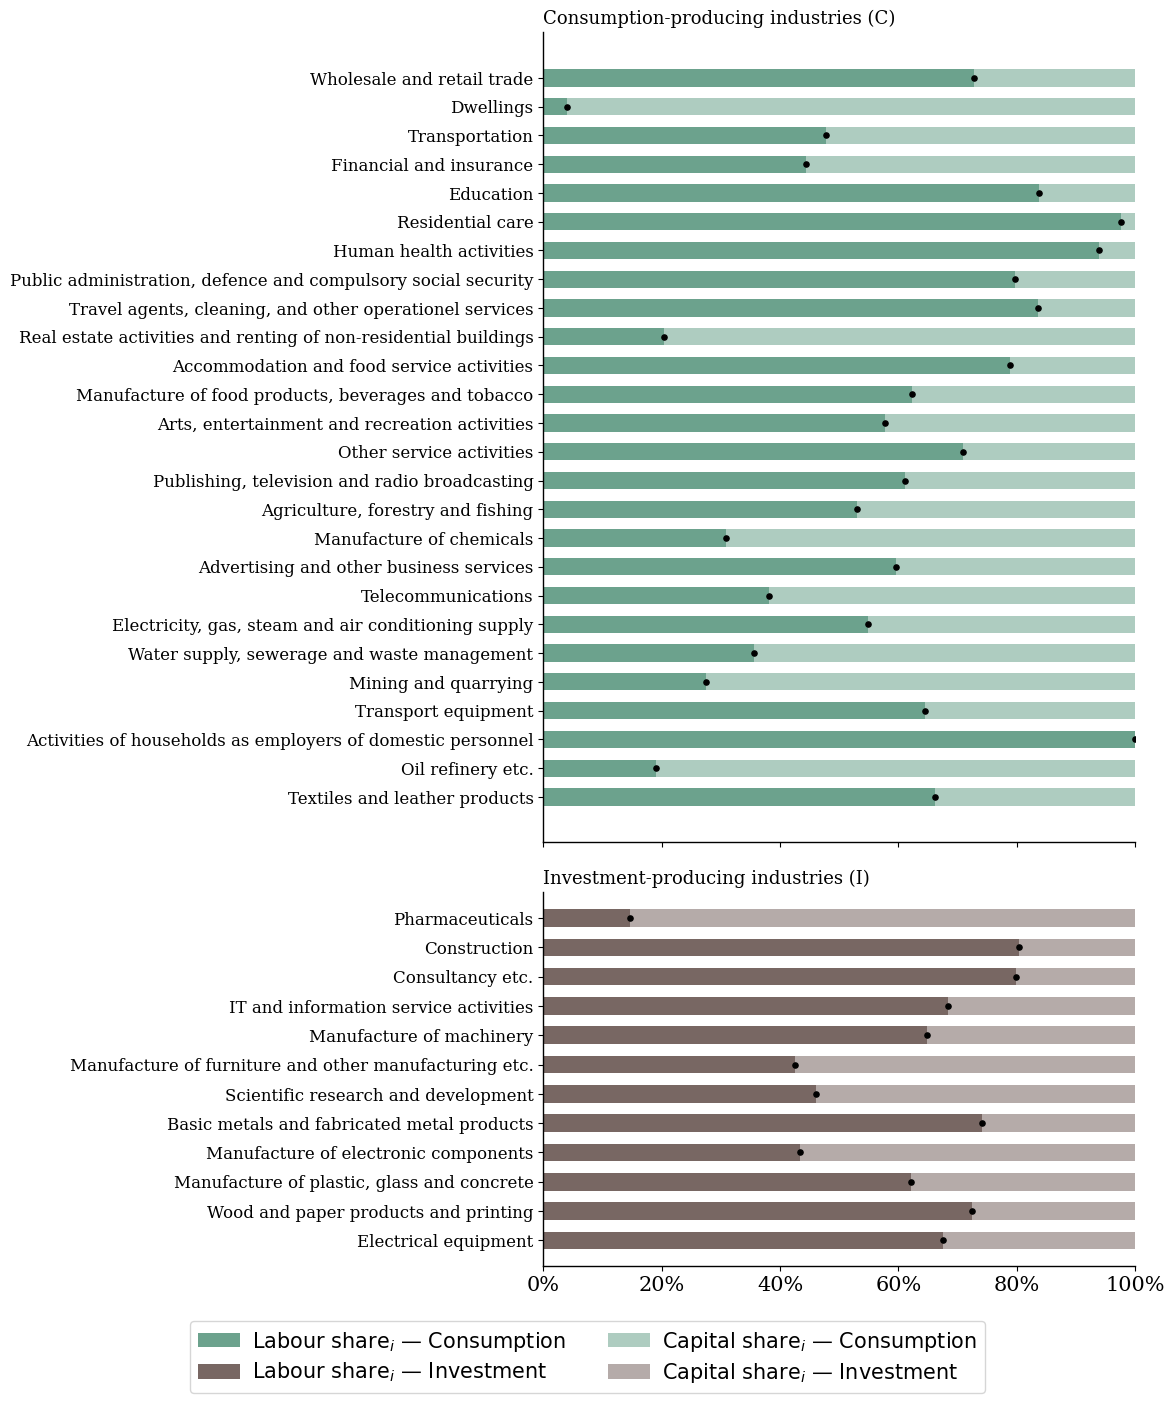

In [346]:
def lighten(hex_color, factor=0.45):
    """Blend a hex color with white by factor (0=original, 1=white)."""
    rgb = np.array(mcolors.to_rgb(hex_color))
    return mcolors.to_hex(rgb + (1 - rgb) * factor)

df = df_24_i.copy()

cons = df[df["type"] == "C"].sort_values("GVA", ascending=True).copy()
inv  = df[df["type"] == "I"].sort_values("GVA", ascending=True).copy()

cons["BRANCHE"] = cons["BRANCHE"].str.replace(r'^[A-Z]+\d*\s+', '', regex=True)
inv["BRANCHE"]  = inv["BRANCHE"].str.replace(r'^[A-Z]+\d*\s+', '', regex=True)

# Base labor colors — capital is auto-lightened
c_lab = "#6CA28D"  # terracotta — consumption labor
i_lab = "#786763"  # teal — investment labor

c_cap = lighten(c_lab)  # light terracotta — consumption capital
i_cap = lighten(i_lab)  # light teal — investment capital

n_cons = len(cons)
n_inv  = len(inv)

fig, axes = plt.subplots(
    2, 1, figsize=(12, 14), sharex=True,
    gridspec_kw={"height_ratios": [n_cons, n_inv]}
)

for ax, block, ttl, lab_color, cap_color in [
    (axes[0], cons, "Consumption-producing industries (C)", c_lab, c_cap),
    (axes[1], inv,  "Investment-producing industries (I)",  i_lab, i_cap),
]:
    y   = np.arange(len(block))
    lab = block["labor_share"].to_numpy()
    cap = 100.0 - lab

    ax.barh(y, lab, color=lab_color, edgecolor="none", height=0.6,
            label="Labour income share")
    ax.barh(y, cap, left=lab, color=cap_color, edgecolor="none", height=0.6,
            label="Capital income share (residual)")

    ax.scatter(lab, y, s=14, color="k", zorder=3)

    ax.set_yticks(y)
    ax.set_yticklabels(block["BRANCHE"], fontsize=12)
    ax.set_xlim(0, 100)
    ax.set_xticks(np.arange(0, 101, 20))
    ax.set_xticklabels([f"{v:d}%" for v in range(0, 101, 20)])

    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

    ax.set_title(ttl, loc="left", fontsize=13)

handles1, labels1 = axes[0].get_legend_handles_labels()
handles2, labels2 = axes[1].get_legend_handles_labels()

# Take labor+capital from each panel
combined_handles = [handles1[0], handles2[0], handles1[1], handles2[1]]
combined_labels  = [
    r"$\text{Labour share}_i     \text{ — Consumption}$",
    r"$\text{Labour share}_i     \text{ — Investment}$",
    r"$\text{Capital share}_i    \text{ — Consumption}$",
    r"$\text{Capital share}_i    \text{ — Investment}$",
]

fig.legend(combined_handles, combined_labels, loc="lower center",
           ncol=2, frameon=True, bbox_to_anchor=(0.5, -0.01))

plt.tight_layout(rect=(0, 0.05, 1, 1))
plt.savefig('0_output/LS_i.png', dpi=200)
plt.show()

In [347]:
# # 1. full category
# plot_data = weighted_avg.pivot(index='TID', columns='type', values='weighted_labor_share')
# plot_data_2 = weighted_avg_np.pivot(index='TID', columns='type', values='weighted_labor_share')

# # compute diff for full category too
# pivoted_full = weighted_avg.pivot(index='TID', columns='type', values='weighted_labor_share').reset_index()
# pivoted_full['diff'] = pivoted_full['I'] - pivoted_full['C']

# fig, ax = plt.subplots(1, 1, figsize=(12, 4))
# ax2 = ax.twinx()

# x = plot_data.index
# types = plot_data.columns.tolist()
# colors = ["#6CA28D", "#786763"]
# lable = ["Consumption sector", "Investment sector"]

# order = sorted(range(len(types)), key=lambda i: plot_data[types[i]].mean(), reverse=True)
# for i in order:
#     ax.fill_between(x, 0, plot_data[types[i]], alpha=1.0, linewidth=0, label=lable[i], color=colors[i])

# ax2.plot(pivoted_full['TID'], pivoted_full['diff'], color='#41FAB4', lw=2,
#          ls='--', label='I − C difference')

# ax.axhline(0, color="0.2", linewidth=1.2)
# ax.set_xlim(x.min(), x.max())
# ax.set_ylim(40, 80)
# ax.grid(linewidth=0.6, alpha=0.35)
# ax.xaxis.set_major_locator(mticker.MaxNLocator(nbins=12))
# ax.set_ylabel('Labour share (%)')
# ax2.set_ylabel('Difference (I − C, pp)')
# ax2.axhline(0, color='white', lw=0.8, alpha=0.4)

# # combined legend
# handles1, labels1 = ax.get_legend_handles_labels()
# handles2, labels2 = ax2.get_legend_handles_labels()
# ax.legend(handles1 + handles2, labels1 + labels2, loc='lower left')

# plt.tight_layout()
# plt.savefig('0_output/LS_1.png')
# plt.show()

# # 2. no pharma
# fig, ax = plt.subplots(1, 1, figsize=(12, 4))
# ax2 = ax.twinx()

# y = plot_data_2.index
# types = plot_data_2.columns.tolist()

# order = sorted(range(len(types)), key=lambda i: plot_data_2[types[i]].mean(), reverse=True)
# for i in order:
#     ax.fill_between(y, 0, plot_data_2[types[i]], alpha=1.0, linewidth=0, label=lable[i], color=colors[i])

# ax2.plot(pivoted['TID'], pivoted['diff'], color='#41FAB4', lw=2,
#          ls='--', label=r'$\Delta(I-C)\; pp.$, no pharma')
# ax2.plot(pivoted_full['TID'], pivoted_full['diff'], color='#F76A4D', lw=2,
#          ls='--', label=r'$\Delta(I-C)\; pp.$')

# ax.axhline(0, color="0.2", linewidth=1.2)
# ax.set_xlim(y.min(), y.max())
# ax.set_ylim(40, 80)
# ax.grid(linewidth=0.6, alpha=0.35)
# ax.xaxis.set_major_locator(mticker.MaxNLocator(nbins=12))
# ax.set_ylabel('Labour share (%)')
# ax2.set_ylabel(r'$\Delta(I-C)\; pp.$')

# handles1, labels1 = ax.get_legend_handles_labels()
# handles2, labels2 = ax2.get_legend_handles_labels()
# ax.legend(handles1 + handles2, labels1 + labels2, loc='lower left')

# fig.suptitle('Labour shares by sectors (%)', y=0.9)
# plt.tight_layout()
# plt.savefig('0_output/LS_2.png')
# plt.show()